# Ejercicio 3

**Consigna:**

En lo que sigue, consideraremos que la variable protegida a analizar será **género**.
Basándonos en trabajos que señalan ciertos sesgos de género, se propone:

a) Describir con palabras cómo se interpretan en este contexto los criterios de fairness vistos en clase: Statistical Parity, Equalized Odds, Equal Opportunity y Predictive Parity.

b) Considerando como medida de disparidad el módulo de la diferencia y seleccionando un umbral definido por ustedes, analizar si el modelo inicial es fair para cada una de las posibles definiciones de fairness estudiadas en el inciso anterior.

c) Recordando que forman parte de la entidad asignada en cada conjunto de datos, ¿cuál de los criterios de fairness le parece relevante en este contexto? Justificar su elección.

---
## Nota sobre el enfoque

El dataset de Bank Marketing **no tiene variable de género**. Como establecimos en el Ej1, usamos **`job` como proxy de género** (los trabajos `housemaid` y `admin.` fueron históricamente femeninos).

Además, realizamos un **análisis paralelo con `marital` como variable protegida oficial** (variable protegida oficial del dataset), ya que el estado civil correlaciona con la etapa de vida.

El ejercicio se resuelve **primero con job (proxy de género)** y luego **con marital (estado civil)**, para evaluar cuál orientación es más adecuada para los ejercicios siguientes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, accuracy_score
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style='whitegrid', palette='muted')

# ---- Pipeline idéntico al Ej2 ----
df = pd.read_csv('data/full.csv', sep=';')
df = df.drop(columns=['duration'])  # data leakage
df = df[df['marital'] != 'unknown'].reset_index(drop=True)
df_original = df.copy()

df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

X = df_encoded.drop(columns=['y'])
y = df_encoded['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

# DataFrame de análisis
test_idx = X_test.index
df_analysis = pd.DataFrame({
    'job': df_original.loc[test_idx, 'job'].values,
    'marital': df_original.loc[test_idx, 'marital'].values,
    'y_true': y_test.values,
    'y_pred': y_pred
})

# Proxy de género
df_analysis['job_group'] = df_analysis['job'].apply(
    lambda x: 'hist_femenino' if x in ['housemaid', 'admin.'] else 'hist_masculino_otro'
)

print('Pipeline cargado. Modelo entrenado.')
print(f'Test: {len(df_analysis)} registros')

Pipeline cargado. Modelo entrenado.
Test: 8222 registros


In [2]:
def calcular_metricas_fairness(df_grupo):
    """Calcula las métricas de fairness para un grupo."""
    yt = df_grupo['y_true']
    yp = df_grupo['y_pred']
    
    # Statistical Parity: P(Y_pred=1 | grupo)
    stat_parity = yp.mean()
    
    # Equal Opportunity (TPR): P(Y_pred=1 | Y=1, grupo)
    tpr = recall_score(yt, yp, zero_division=0)
    
    # Predictive Parity (Precision): P(Y=1 | Y_pred=1, grupo)
    prec = precision_score(yt, yp, zero_division=0)
    
    # FPR para Equalized Odds: P(Y_pred=1 | Y=0, grupo)
    fp = ((yt == 0) & (yp == 1)).sum()
    tn = ((yt == 0) & (yp == 0)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    return pd.Series({
        'Statistical Parity': stat_parity,
        'Equal Opportunity (TPR)': tpr,
        'Predictive Parity (Precision)': prec,
        'TPR (Equalized Odds)': tpr,
        'FPR (Equalized Odds)': fpr
    })

print('Funciones de fairness definidas.')

Funciones de fairness definidas.


---
# PARTE 1: `job` como proxy de género

Grupos: **hist_femenino** (`housemaid`, `admin.`) vs. **hist_masculino_otro** (resto)

## a) Criterios de fairness en contexto (proxy de género via `job`)

1. **Statistical Parity**: El modelo predice suscripción en **igual proporción** para empleos históricamente femeninos que para los demás. Es decir, si predecimos que el 10% de las personas en trabajos 'femeninos' se suscribirán, deberíamos predecir lo mismo para el otro grupo. No importa si realmente se suscriben o no.

2. **Equal Opportunity**: Dado que el objetivo del banco es encontrar suscriptores, queremos que entre las personas que **sí se iban a suscribir**, el modelo las detecte igual de bien sin importar si tienen un trabajo históricamente femenino o no. Es decir, el **Recall (TPR)** debe ser similar entre grupos.

3. **Equalized Odds**: Más exigente que Equal Opportunity. Pide que tanto el TPR como el FPR sean iguales entre grupos. En nuestro contexto, además de detectar igual proporción de verdaderos suscriptores, queremos que la tasa de 'falsas alarmas' (llamar a alguien que no se suscribirá) sea similar. Esto es relevante porque si llamamos innecesariamente más a un grupo, estamos generando una molestia desproporcionada.

4. **Predictive Parity**: Cuando el modelo dice 'esta persona se suscribe', la **confianza** (Precisión) de esa predicción debe ser igual para ambos grupos. Es decir, si predecimos que alguien en un trabajo 'femenino' se suscribirá, la probabilidad de que realmente lo haga debe ser la misma que para el otro grupo.

## b) Análisis cuantitativo de fairness (proxy de género)

Usamos como medida de disparidad el **módulo de la diferencia** entre las métricas de ambos grupos. Seleccionamos un **umbral de 0.1** (10%), una elección estándar en la literatura de fairness.

--- Métricas de Fairness por Grupo (job) ---
                     Statistical Parity  Equal Opportunity (TPR)  Predictive Parity (Precision)  TPR (Equalized Odds)  FPR (Equalized Odds)
Grupo                                                                                                                                      
hist_femenino                  0.065139                 0.315436                       0.648276              0.315436              0.026452
hist_masculino_otro            0.053202                 0.296178                       0.583072              0.296178              0.024776

--- Disparidades (umbral = 0.1) ---
Statistical Parity: 0.0119 → ✅ FAIR
Equal Opportunity (TPR): 0.0193 → ✅ FAIR
Predictive Parity (Precision): 0.0652 → ✅ FAIR
TPR (Equalized Odds): 0.0193 → ✅ FAIR
FPR (Equalized Odds): 0.0017 → ✅ FAIR


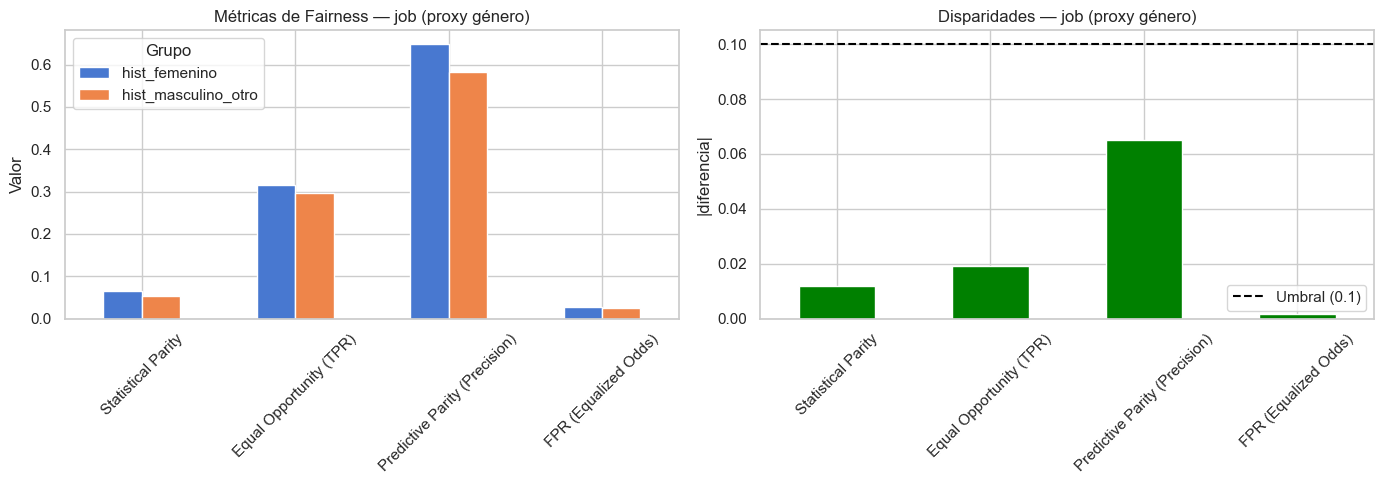

In [3]:
# Calcular métricas por grupo (job)
grupos_job = ['hist_femenino', 'hist_masculino_otro']
metricas_job = {}
for grupo in grupos_job:
    mask = df_analysis['job_group'] == grupo
    metricas_job[grupo] = calcular_metricas_fairness(df_analysis[mask])

df_metricas_job = pd.DataFrame(metricas_job).T
df_metricas_job.index.name = 'Grupo'

print('--- Métricas de Fairness por Grupo (job) ---')
print(df_metricas_job.to_string())
print()

# Disparidades
disparidad_job = (df_metricas_job.loc['hist_femenino'] - df_metricas_job.loc['hist_masculino_otro']).abs()
umbral = 0.1

print(f'--- Disparidades (umbral = {umbral}) ---')
for metrica, valor in disparidad_job.items():
    fair = '✅ FAIR' if valor < umbral else '❌ NO FAIR'
    print(f'{metrica}: {valor:.4f} → {fair}')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Métricas por grupo
df_metricas_job[['Statistical Parity', 'Equal Opportunity (TPR)', 
                  'Predictive Parity (Precision)', 'FPR (Equalized Odds)']].T.plot(
    kind='bar', ax=axes[0]
)
axes[0].set_title('Métricas de Fairness — job (proxy género)')
axes[0].set_ylabel('Valor')
axes[0].legend(title='Grupo')
axes[0].tick_params(axis='x', rotation=45)

# Disparidades vs umbral
disp_plot = disparidad_job[['Statistical Parity', 'Equal Opportunity (TPR)',
                             'Predictive Parity (Precision)', 'FPR (Equalized Odds)']]
colors = ['green' if v < umbral else 'red' for v in disp_plot.values]
disp_plot.plot(kind='bar', ax=axes[1], color=colors)
axes[1].axhline(y=umbral, color='black', linestyle='--', label=f'Umbral ({umbral})')
axes[1].set_title('Disparidades — job (proxy género)')
axes[1].set_ylabel('|diferencia|')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## c) ¿Cuál criterio de fairness es más relevante? (proxy de género)

En el contexto de marketing bancario donde el objetivo es **incrementar la tasa de suscripción**, consideramos que el criterio más relevante es **Equal Opportunity**.

### Justificación:

1. **Alineación con el objetivo de negocio**: Nos interesa que entre las personas que **realmente se habrían suscrito**, el modelo las identifique con la misma probabilidad sin importar su tipo de trabajo (y por extensión, su género inferido). No queremos que el banco pierda más suscriptores potenciales de un grupo que de otro.

2. **Coherencia con el inciso b del Ej2**: Identificamos al Falso Negativo como el error más crítico. Equal Opportunity mide exactamente si la tasa de FN es equitativa entre grupos, ya que un TPR más bajo = más FN.

3. **Statistical Parity no es lo ideal** porque no distingue entre predicciones correctas e incorrectas. Si un grupo efectivamente tiene mayor tasa de suscripción, forzar paridad estadística sería contraproducente.

4. **Equalized Odds es demasiado exigente** para este contexto. Si bien igualar el FPR es deseable (no molestar desproporcionadamente a un grupo con llamadas innecesarias), el costo de un FP es marginal comparado con el de un FN. Priorizamos detectar suscriptores.

5. **Predictive Parity es secundaria**: la confianza de la predicción importa, pero es menos crítica que asegurar que no se pierdan suscriptores de ningún grupo.

---
# PARTE 2: `marital` como variable protegida oficial

Grupos: **married**, **single**, **divorced**

El estado civil es una de las variables protegidas oficiales del dataset. Como señalamos en el Ej1, correlaciona con la edad (single → joven, married → mediana edad, divorced → mayor) y además presenta desbalances en representación.

## a) Criterios de fairness en contexto (marital como variable protegida)

1. **Statistical Parity**: El modelo predice suscripción en igual proporción para casados, solteros y divorciados. Es decir, la *tasa de predicción positiva* debe ser similar entre los tres estados civiles, independientemente de si realmente se suscriben.

2. **Equal Opportunity**: Entre los clientes que **sí se iban a suscribir**, el modelo los detecta con la misma eficacia sin importar su estado civil. Queremos que el banco no pierda más suscriptores potenciales entre los solteros (jóvenes) que entre los casados (mediana edad), por ejemplo.

3. **Equalized Odds**: Además de detectar igual proporción de suscriptores (TPR), las 'falsas alarmas' (FPR) deben ser similares entre grupos. En nuestro contexto, esto significa que el banco no debería estar llamando innecesariamente más a personas casadas que a solteras o divorciadas.

4. **Predictive Parity**: Cuando el modelo predice que alguien se suscribirá, esa predicción debe ser igualmente confiable sin importar si la persona es casada, soltera o divorciada.

## b) Análisis cuantitativo de fairness (marital)

Con tres grupos, calculamos la disparidad como la **máxima diferencia absoluta** entre cualquier par de grupos para cada métrica. Umbral: **0.1**.

--- Métricas de Fairness por Grupo (marital) ---
          Statistical Parity  Equal Opportunity (TPR)  Predictive Parity (Precision)  TPR (Equalized Odds)  FPR (Equalized Odds)
Grupo                                                                                                                           
married             0.045895                 0.273622                       0.599138              0.273622              0.020453
single              0.083624                 0.348348                       0.604167              0.348348              0.038716
divorced            0.045924                 0.294118                       0.625000              0.294118              0.019084

--- Disparidades máximas entre pares (umbral = 0.1) ---
Statistical Parity: 0.0377 (married vs single) → ✅ FAIR
Equal Opportunity (TPR): 0.0747 (married vs single) → ✅ FAIR
Predictive Parity (Precision): 0.0259 (married vs divorced) → ✅ FAIR
TPR (Equalized Odds): 0.0747 (married vs single) → ✅ FAIR
FPR (

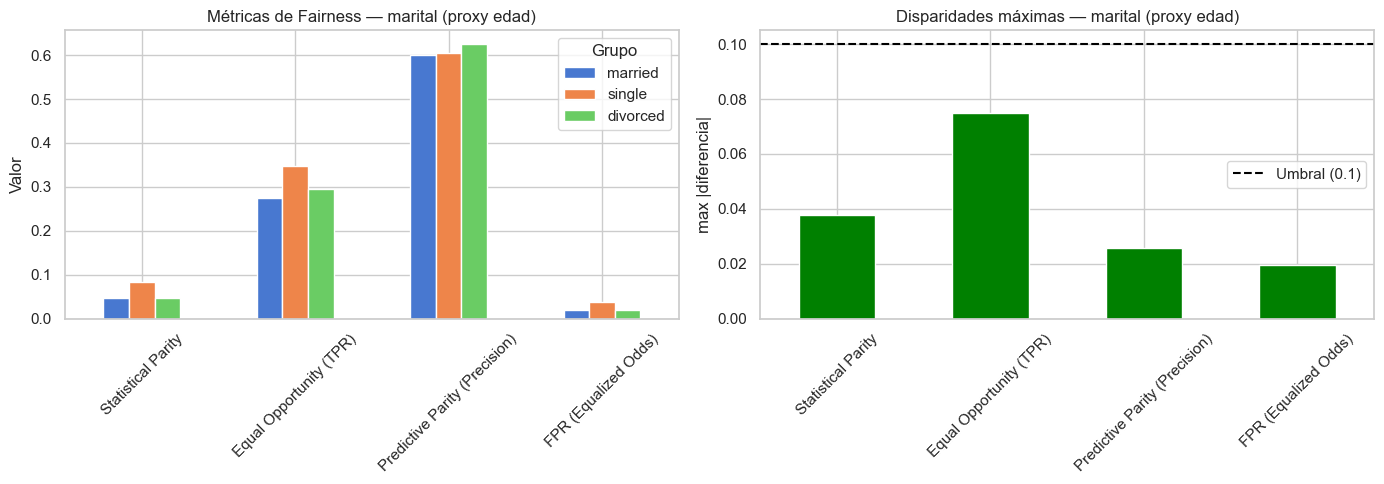

In [4]:
# Calcular métricas por grupo (marital)
grupos_mar = ['married', 'single', 'divorced']
metricas_mar = {}
for grupo in grupos_mar:
    mask = df_analysis['marital'] == grupo
    metricas_mar[grupo] = calcular_metricas_fairness(df_analysis[mask])

df_metricas_mar = pd.DataFrame(metricas_mar).T
df_metricas_mar.index.name = 'Grupo'

print('--- Métricas de Fairness por Grupo (marital) ---')
print(df_metricas_mar.to_string())
print()

# Disparidad máxima entre pares
from itertools import combinations
umbral = 0.1
print(f'--- Disparidades máximas entre pares (umbral = {umbral}) ---')
disparidad_mar = {}
for metrica in df_metricas_mar.columns:
    max_disp = 0
    peor_par = ''
    for g1, g2 in combinations(grupos_mar, 2):
        d = abs(df_metricas_mar.loc[g1, metrica] - df_metricas_mar.loc[g2, metrica])
        if d > max_disp:
            max_disp = d
            peor_par = f'{g1} vs {g2}'
    disparidad_mar[metrica] = max_disp
    fair = '✅ FAIR' if max_disp < umbral else '❌ NO FAIR'
    print(f'{metrica}: {max_disp:.4f} ({peor_par}) → {fair}')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cols_plot = ['Statistical Parity', 'Equal Opportunity (TPR)',
             'Predictive Parity (Precision)', 'FPR (Equalized Odds)']

# Métricas por grupo
df_metricas_mar[cols_plot].T.plot(kind='bar', ax=axes[0])
axes[0].set_title('Métricas de Fairness — marital (estado civil)')
axes[0].set_ylabel('Valor')
axes[0].legend(title='Grupo')
axes[0].tick_params(axis='x', rotation=45)

# Disparidades vs umbral
disp_series = pd.Series({k: disparidad_mar[k] for k in cols_plot})
colors = ['green' if v < umbral else 'red' for v in disp_series.values]
disp_series.plot(kind='bar', ax=axes[1], color=colors)
axes[1].axhline(y=umbral, color='black', linestyle='--', label=f'Umbral ({umbral})')
axes[1].set_title('Disparidades máximas — marital (estado civil)')
axes[1].set_ylabel('max |diferencia|')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## c) ¿Cuál criterio de fairness es más relevante? (marital como variable protegida)

Nuevamente, consideramos que **Equal Opportunity** es el criterio más relevante.

### Justificación:

1. **Equidad entre grupos de edad/estado civil**: El banco debe detectar a los potenciales suscriptores con la misma eficacia sin importar si son casados, solteros o divorciados. Si el modelo tiene menor Recall para divorciados (subrepresentados), está discriminando contra ese grupo.

2. **Sub-representación → sesgo**: Como identificamos en el Ej1, el grupo `married` representa ~60% del dataset. El modelo podría generalizar bien para casados pero fallar con solteros y divorciados. Equal Opportunity captura exactamente este problema.

3. **Costo asimétrico (coherencia con Ej2)**: Dado que el FN es peor que el FP, el criterio que directamente mide la tasa de FN por grupo (Equal Opportunity = TPR) es el más relevante.

4. Si bien intentaremos reducir los falsos positivos, preferimos asegurar que los verdaderos positivos sean detectados equitativamente antes que igualar las falsas alarmas (Equalized Odds). Dado que tenemos muchas más observaciones de `married` que de `divorced` y `single`, esto puede causar que el modelo generalice mucho mejor para los primeros.

---

### Conclusión comparativa

Ambos análisis (job como proxy de género y marital como variable protegida) convergen en la misma elección de criterio: **Equal Opportunity**. Esto refuerza la coherencia del trabajo y sugiere que para los ejercicios 4 y 5, la mitigación debe enfocarse en igualar el TPR entre los grupos protegidos.